In [1]:
import pandas as pd
df = pd.read_csv("D:\Customer-Intelligence-Growth-Analytics/data/processed/telco_customer_clean.csv")


In [2]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.head()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
0,1,90003,33.964131,-118.272783,2,53.85,108.15,1,86,3239
1,1,90005,34.059281,-118.307420,2,70.70,151.65,1,67,2701
2,1,90006,34.048013,-118.293953,8,99.65,820.50,1,86,5372
3,1,90010,34.062125,-118.315709,28,104.80,3046.05,1,84,5003
4,1,90015,34.039224,-118.266293,49,103.70,5036.30,1,89,5340


In [3]:
corr = numeric_df.corr()

corr

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.000884,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.009944,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.008876,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.826178,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651174,0.193356,0.133754,0.098693
Total Charges,NaN,-0.000884,-0.009944,0.008876,0.826178,0.651174,1.000000,-0.198324,-0.123410,0.342091
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.198324,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.123410,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.342091,-0.127463,-0.079782,1.000000


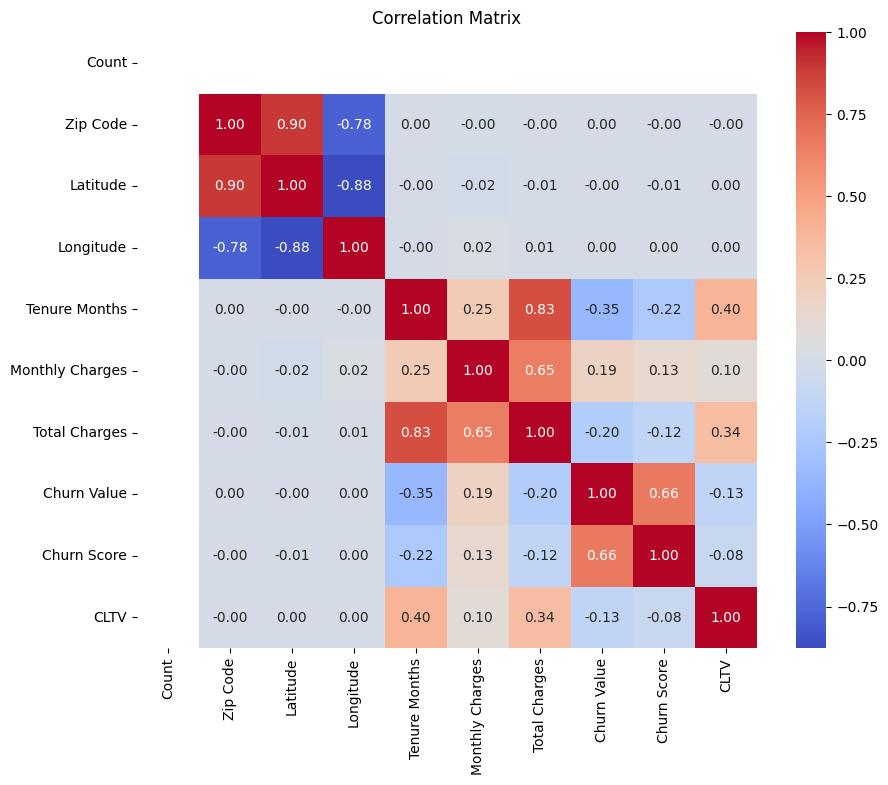

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [5]:
monthly = (
    df.groupby("Churn Label")
      ["Monthly Charges"]
      .mean()
      .reset_index()
)

monthly

,Churn Label,Monthly Charges
0,No,61.265124
1,Yes,74.441332


In [6]:
tenure = (
    df.groupby("Churn Label")
      ["Tenure Months"]
      .mean()
      .reset_index()
)

tenure

,Churn Label,Tenure Months
0,No,37.569965
1,Yes,17.979133


In [7]:
cltv = (
    df.groupby("Churn Label")
      ["CLTV"]
      .mean()
      .reset_index()
)

cltv

,Churn Label,CLTV
0,No,4490.921337
1,Yes,4149.414660


In [8]:
score = (
    df.groupby("Churn Label")
      ["Churn Score"]
      .mean()
      .reset_index()
)

score

,Churn Label,Churn Score
0,No,50.098183
1,Yes,82.510433


In [9]:
risk_profile = (
    df.groupby(
        ["Contract",
         "Payment Method",
         "Internet Service"]
    )
    .agg(
        Customers=("CustomerID","count"),
        Churn_Rate=("Churn Value","mean")
    )
    .reset_index()
)

risk_profile["Churn_Rate"] = (
    risk_profile["Churn_Rate"] * 100
).round(2)

risk_profile.sort_values(
    "Churn_Rate",
    ascending=False
)

,Contract,Payment Method,Internet Service,Customers,Churn_Rate
7,Month-to-month,Electronic check,Fiber optic,1307,60.37
10,Month-to-month,Mailed check,Fiber optic,201,50.75
1,Month-to-month,Bank transfer (automatic),Fiber optic,327,45.57
4,Month-to-month,Credit card (automatic),Fiber optic,293,41.64
6,Month-to-month,Electronic check,DSL,474,40.51
9,Month-to-month,Mailed check,DSL,367,30.79
3,Month-to-month,Credit card (automatic),DSL,185,27.03
19,One year,Electronic check,Fiber optic,196,26.02
11,Month-to-month,Mailed check,No,325,20.62
2,Month-to-month,Bank transfer (automatic),No,65,20.00
